In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
import pandas as pd
from scipy.interpolate import CubicSpline  # Changed from interp1d

In [73]:
def calculate_max_range(data_array):
    """
    Calculates the maximum peak-to-peak range of a given 1D array or list.
    
    Parameters:
    data_array (array-like): The numerical data (e.g., length or velocity).
    
    Returns:
    float: The total range (maximum value - minimum value).
    """
    # Convert to a numpy array just in case a standard Python list is passed
    arr = np.asarray(data_array)
    
    # Calculate and return the difference between the absolute max and min
    return np.max(arr) - np.min(arr)

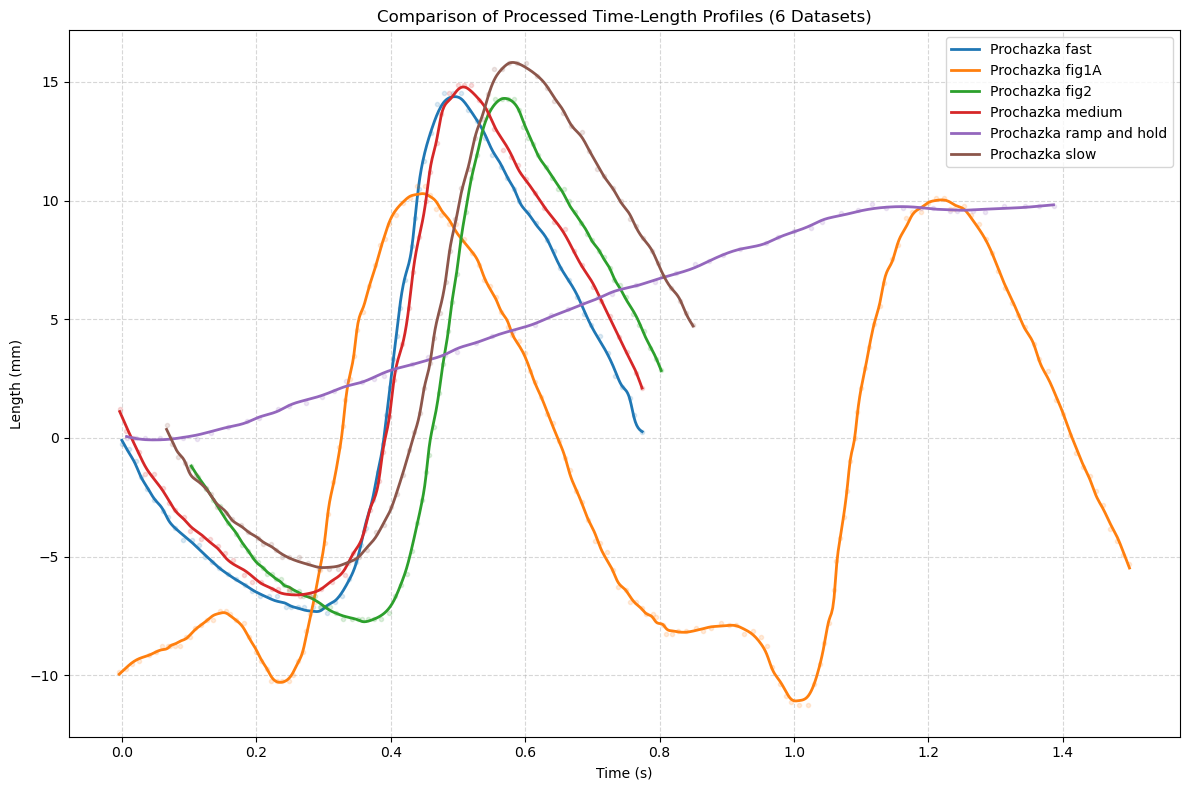

In [55]:
# 1. Define the list of your 6 files
file_names = [
    'Prochazka fast.csv',
    'Prochazka fig1A.csv',  # Replace with your actual file names
    'Prochazka fig2.csv', 
    'Prochazka medium.csv',
    'Prochazka ramp and hold.csv',
    'Prochazka slow.csv'
]

# Dictionary to hold the processed data in memory without saving files
processed_data = {}

# Set up a plot to visualize all 6 datasets together
plt.figure(figsize=(12, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 2. Loop through each file and apply the processing
for i, file_path in enumerate(file_names):
    try:
        df = pd.read_csv(file_path, header=None)
        time = df[0].values
        length = df[1].values
        
        # 1. Light pre-smooth just to remove raw digitizer noise
        smooth_length = savgol_filter(length, window_length=13, polyorder=3)
        
        # 2. Use CubicSpline instead of interp1d
        # bc=type='natural' ensures smooth behavior at the boundaries
        cs = CubicSpline(time, smooth_length, bc_type='natural')
        
        # 3. Generate your dense 1000-point grid
        time_dense = np.linspace(time.min(), time.max(), 750)
        length_interpolated = cs(time_dense)

        # 4. FIXED: Get the exact, analytical mathematical derivative 
        # This completely avoids the noise spikes of np.gradient
        cs_derivative = cs.derivative()
        velocity = cs_derivative(time_dense)
        
        # 5. Optional: A very light smooth on velocity if your raw data was incredibly noisy
        velocity = savgol_filter(velocity, window_length=111, polyorder=2)

        # Firing Rate
        firing_rate = 4.3 * (np.sign(velocity) * np.abs(velocity)**0.6) + 2 * length_interpolated + 82
        
        # Derive a clean name from the filename for tracking
        dataset_name = file_path.replace('.csv', '').replace('_', ' ')
        
        # Store the numpy arrays in our dictionary
        processed_data[dataset_name] = {
            'time': time_dense,
            'length': length_interpolated,
            'velocity': velocity,
            'firing rate': firing_rate
        }
        
        # Plot the smooth curve for this dataset
        plt.plot(time_dense, length_interpolated, label=dataset_name, color=colors[i % len(colors)], linewidth=2)
        # Optional: plot original points faintly behind the curves
        plt.plot(time, length, 'o', color=colors[i % len(colors)], alpha=0.15, markersize=3)
        
    except FileNotFoundError:
        print(f"Warning: Could not find file '{file_path}'. Skipping.")
    except Exception as e:
        print(f"Error processing '{file_path}': {e}")

# 3. Finalize and display the combined plot
plt.xlabel('Time (s)')
plt.ylabel('Length (mm)')
plt.title('Comparison of Processed Time-Length Profiles (6 Datasets)')
plt.legend(frameon=True, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- How to access the data later in your script ---
# Example: To grab the array for 'Prochazka fast' later on, you would write:
# fast_time = processed_data['Prochazka fast']['time']
# fast_length = processed_data['Prochazka fast']['length']

Text(0.5, 0, 'time (s)')

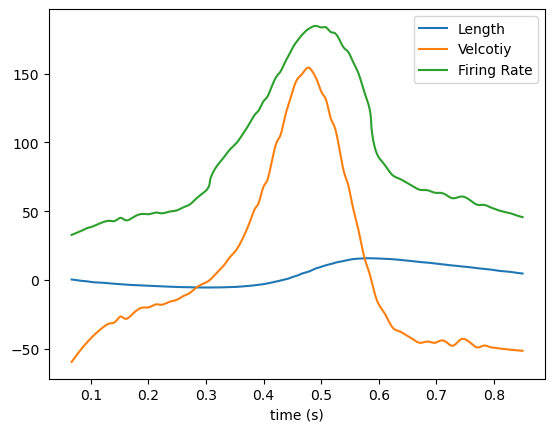

In [61]:
plt.plot(processed_data['Prochazka slow']['time'], processed_data['Prochazka slow']['length'], label = "Length")
plt.plot(processed_data['Prochazka slow']['time'], processed_data['Prochazka slow']['velocity'], label = "Velcotiy")
plt.plot(processed_data['Prochazka slow']['time'], processed_data['Prochazka slow']['firing rate'], label = "Firing Rate")
plt.legend()
plt.xlabel("time (s)")

In [65]:
print("Max Speed Slow: ",max(processed_data['Prochazka slow']['velocity']))
print("Max Speed Medium: ",max(processed_data['Prochazka medium']['velocity']))
print("Max Speed Fast: ",max(processed_data['Prochazka fast']['velocity']))

print("\nMax firing rate Slow: ",max(processed_data['Prochazka slow']['firing rate']))
print("Max firing rate Medium: ",max(processed_data['Prochazka medium']['firing rate']))
print("Max firing rate Fast: ",max(processed_data['Prochazka fast']['firing rate']))

Max Speed Slow:  154.3435656116728
Max Speed Medium:  183.17007754986693
Max Speed Fast:  206.4747251166197

Max firing rate Slow:  184.66314762035972
Max firing rate Medium:  192.7133881357787
Max firing rate Fast:  200.12644595593162


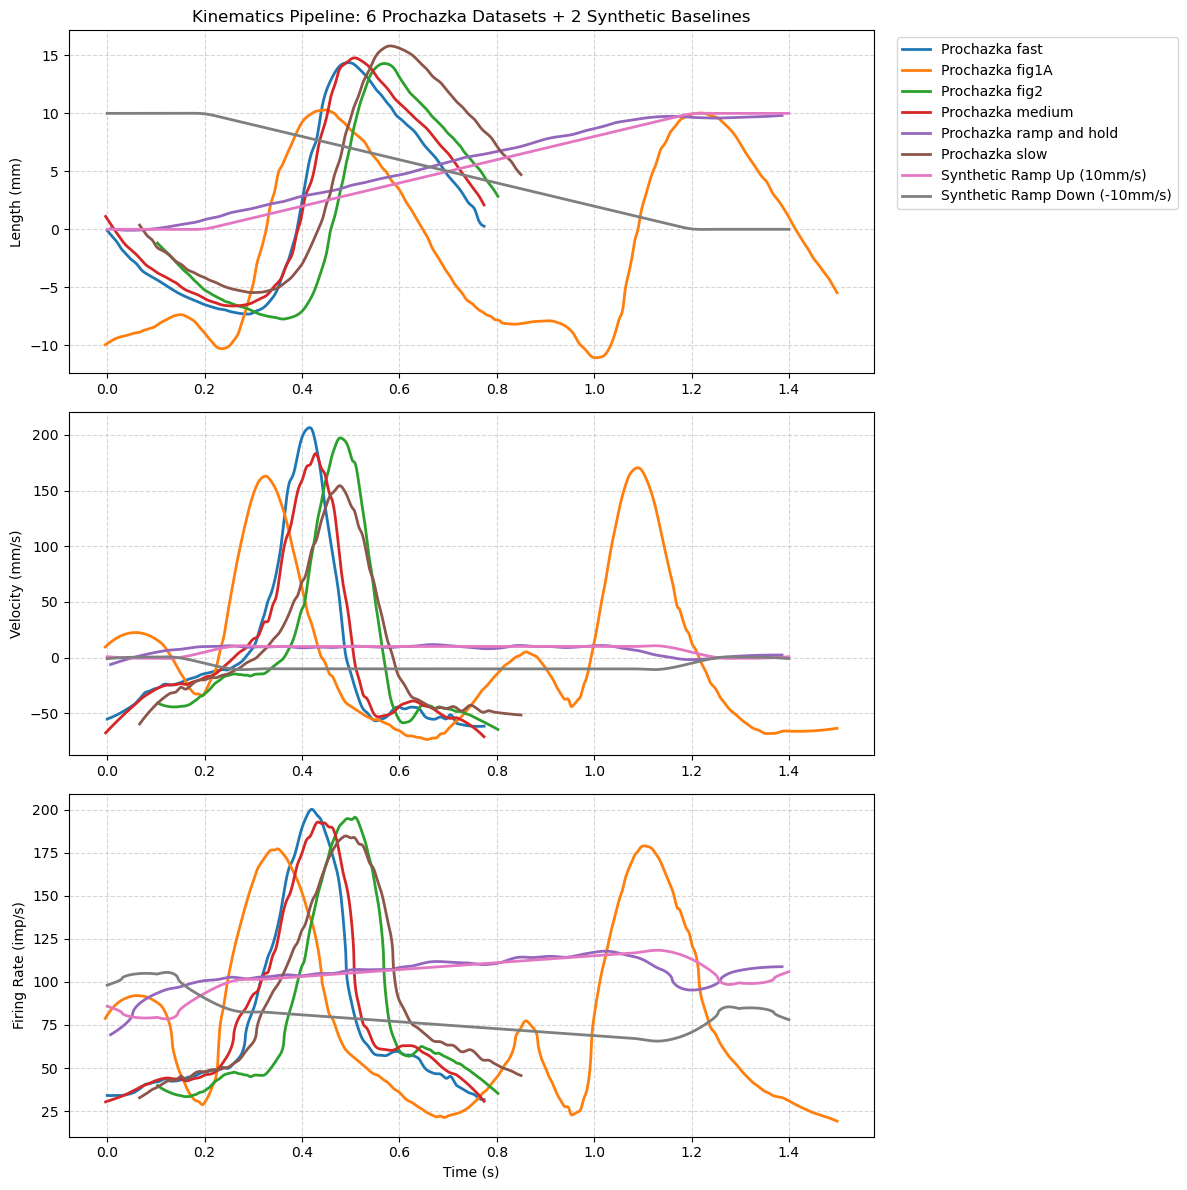

In [71]:
file_names = [
    'Prochazka fast.csv',
    'Prochazka fig1A.csv',
    'Prochazka fig2.csv',
    'Prochazka medium.csv',
    'Prochazka ramp and hold.csv',
    'Prochazka slow.csv'
]

# 1. Gather all raw data (Real + Synthetic) into a single dictionary
all_raw_data = {}

# --- Load Real CSV Data ---
for file_path in file_names:
    try:
        df = pd.read_csv(file_path, header=None)
        dataset_name = file_path.replace('.csv', '').replace('_', ' ')
        all_raw_data[dataset_name] = {
            'time': df[0].values,
            'length': df[1].values
        }
    except FileNotFoundError:
        print(f"Warning: Could not find file '{file_path}'. Skipping.")
    except Exception as e:
        print(f"Error processing '{file_path}': {e}")

# --- Generate Synthetic Data ---
t_synth = np.linspace(0, 1.4, 1400)

# Ramp Up: 0 to 10mm (0.2s hold, 1s ramp, 0.2s hold)
l_up_raw = np.piecewise(
    t_synth, 
    [t_synth < 0.2, (t_synth >= 0.2) & (t_synth <= 1.2), t_synth > 1.2], 
    [0, lambda t: 10 * (t - 0.2), 10]
)

# Ramp Down: 10 to 0mm (0.2s hold, 1s ramp, 0.2s hold)
l_down_raw = np.piecewise(
    t_synth, 
    [t_synth < 0.2, (t_synth >= 0.2) & (t_synth <= 1.2), t_synth > 1.2], 
    [10, lambda t: 10 - 10 * (t - 0.2), 0]
)

# Soften the sharp mathematical corners of the synthetic data to simulate physical movement
all_raw_data['Synthetic Ramp Up (10mm/s)'] = {
    'time': t_synth,
    'length': savgol_filter(l_up_raw, window_length=81, polyorder=3)
}
all_raw_data['Synthetic Ramp Down (-10mm/s)'] = {
    'time': t_synth,
    'length': savgol_filter(l_down_raw, window_length=81, polyorder=3)
}

# 2. Process all 8 datasets through the single pipeline
processed_data = {}

# Set up a 3-panel plot layout
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
colors = plt.cm.tab10.colors  # 10 distinct colors for the 8 lines

for i, (name, data) in enumerate(all_raw_data.items()):
    time = data['time']
    length = data['length']
    
    # Pre-smooth length
    smooth_length = savgol_filter(length, window_length=13, polyorder=3)
    
    # Cubic Spline Interpolation
    cs = CubicSpline(time, smooth_length, bc_type='natural')
    time_dense = np.linspace(time.min(), time.max(), 750)
    length_interpolated = cs(time_dense)

    # Analytical Derivative for Velocity
    cs_derivative = cs.derivative()
    velocity = cs_derivative(time_dense)
    
    # Smooth Velocity (Wide window to fix the noise issue from earlier)
    velocity = savgol_filter(velocity, window_length=111, polyorder=2)

    # Firing Rate Equation
    firing_rate = 4.3 * (np.sign(velocity) * np.abs(velocity)**0.6) + 2 * length_interpolated + 82
    
    # Store the processed arrays
    processed_data[name] = {
        'time': time_dense,
        'length': length_interpolated,
        'velocity': velocity,
        'firing rate': firing_rate
    }
    
    # Plotting
    c = colors[i % len(colors)]
    axes[0].plot(time_dense, length_interpolated, label=name, color=c, linewidth=2)
    axes[1].plot(time_dense, velocity, color=c, linewidth=2)
    axes[2].plot(time_dense, firing_rate, color=c, linewidth=2)

# 3. Finalize plot formatting
axes[0].set_ylabel('Length (mm)')
axes[0].set_title('Kinematics Pipeline: 6 Prochazka Datasets + 2 Synthetic Baselines')
# Move legend outside the plot so it doesn't cover data peaks
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_ylabel('Velocity (mm/s)')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].set_ylabel('Firing Rate (imp/s)')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [75]:
print("--- Maximum Length Ranges ---")
for name, data in processed_data.items():
    
    # Extract the length array for this specific dataset
    length_array = data['length']
    
    # Pass it through our function
    max_range = calculate_max_range(length_array)
    
    # Print the result formatted to 2 decimal places
    print(f"{name}: {max_range:.2f} mm")

--- Maximum Length Ranges ---
Prochazka fast: 21.69 mm
Prochazka fig1A: 21.37 mm
Prochazka fig2: 22.05 mm
Prochazka medium: 21.40 mm
Prochazka ramp and hold: 9.90 mm
Prochazka slow: 21.28 mm
Synthetic Ramp Up (10mm/s): 10.02 mm
Synthetic Ramp Down (-10mm/s): 10.02 mm
